In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("https://raw.githubusercontent.com/anshikavashistha/Hotel_price_analysis/refs/heads/main/Multi-Year%20Price%20Data%20(Aggregate).csv")
df["Date"]      = pd.to_datetime(df["Date"])
df["Year"]      = df["Date"].dt.year
df["Month"]     = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear

colors_year = {2012:"#2196F3", 2013:"#4CAF50", 2014:"#FF9800", 2015:"#9C27B0", 2016:"#F44336"}
years = sorted(df["Year"].unique())
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# df now has 5 cols: Date, Price + Year, Month, DayOfYear (derived)
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Price range: ${df['Price'].min()} – ${df['Price'].max()}")
df.head()

Dataset shape: (1476, 5)
Date range: 2012-01-01 to 2016-01-16
Price range: $81 – $281


,Date,Price,Year,Month,DayOfYear
0,2012-01-01,99,2012,1,1
1,2012-01-02,95,2012,1,2
2,2012-01-03,96,2012,1,3
3,2012-01-04,95,2012,1,4
4,2012-01-05,93,2012,1,5


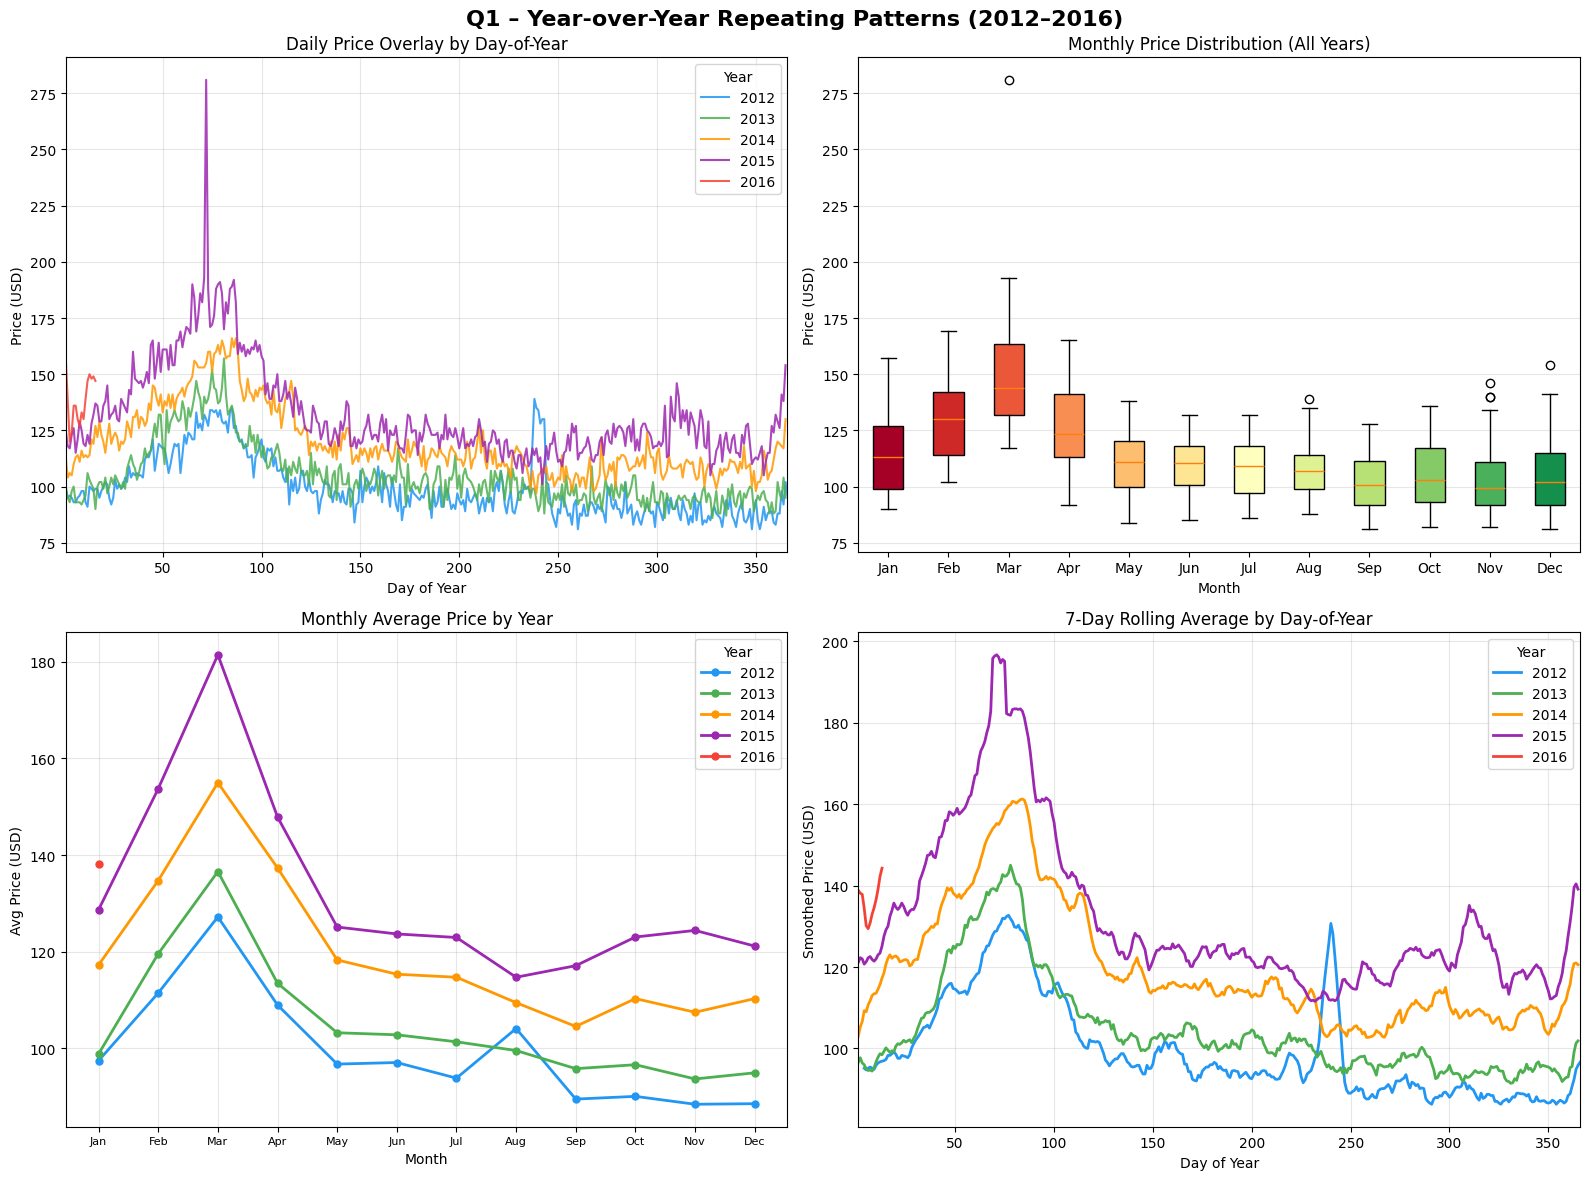


FINDINGS – Q1:
- Strong seasonal pattern: prices are lowest in Sep, Nov, Dec
  (avg $102–$104), peaking in Mar (avg $150).
- Mar is consistently the most expensive month across all years.
- Upward trend: avg price rose from $99 (2012) → $138 (2016),
  indicating steady demand growth over time.
- 2015 shows an unusually high Mar–Apr spike — explored further in Q2.



In [23]:
# ─────────────────────────────────────────────────────────────────
# Q1: Year-over-Year Repeating Patterns
#
# Approach: Overlay all years on the same Day-of-Year axis so any
# repeating seasonal structure is immediately visible. Four views:
#   - Raw daily overlay → same shape repeats every year
#   - Monthly box plots → which months are consistently expensive
#   - Monthly avg per year → pattern holds across all years
#   - 7-day rolling avg → smooths noise to reveal trend shape
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q1 – Year-over-Year Repeating Patterns (2012–2016)", fontsize=16, fontweight="bold")

ax = axes[0,0]
for yr in years:
    sub = df[df["Year"] == yr]
    ax.plot(sub["DayOfYear"], sub["Price"], color=colors_year[yr], alpha=0.85, linewidth=1.5, label=str(yr))
ax.set(title="Daily Price Overlay by Day-of-Year", xlabel="Day of Year", ylabel="Price (USD)", xlim=(1,366))
ax.legend(title="Year"); ax.grid(alpha=0.3)

ax = axes[0,1]
bp = ax.boxplot([df[df["Month"]==m]["Price"].values for m in range(1,13)],
                patch_artist=True, tick_labels=month_names)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(plt.cm.RdYlGn(i/12))
ax.set(title="Monthly Price Distribution (All Years)", xlabel="Month", ylabel="Price (USD)")
ax.grid(alpha=0.3, axis="y")

ax = axes[1,0]
for yr in years:
    sub = df[df["Year"]==yr].groupby("Month")["Price"].mean()
    ax.plot(sub.index, sub.values, color=colors_year[yr], marker="o", linewidth=2, markersize=5, label=str(yr))
ax.set(title="Monthly Average Price by Year", xlabel="Month", ylabel="Avg Price (USD)")
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8)
ax.legend(title="Year"); ax.grid(alpha=0.3)

ax = axes[1,1]
df_s = df.sort_values("Date").copy()
df_s["Rolling7"] = df_s["Price"].rolling(7, center=True).mean()
for yr in years:
    sub = df_s[df_s["Year"]==yr]
    ax.plot(sub["DayOfYear"], sub["Rolling7"], color=colors_year[yr], linewidth=2, label=str(yr))
ax.set(title="7-Day Rolling Average by Day-of-Year", xlabel="Day of Year", ylabel="Smoothed Price (USD)", xlim=(1,366))
ax.legend(title="Year"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

monthly_avg        = df.groupby("Month")["Price"].mean()
peak_month         = monthly_avg.idxmax()
peak_price         = monthly_avg.max()
monthly_avg_sorted = monthly_avg.sort_values()
low_months_str     = ", ".join([month_names[m-1] for m in monthly_avg_sorted.head(3).index])
low_range_low      = monthly_avg_sorted.iloc[0]
low_range_high     = monthly_avg_sorted.iloc[2]
avg_2012           = df[df["Year"]==2012]["Price"].mean()
avg_last           = df[df["Year"]==years[-1]]["Price"].mean()

print(f"""
FINDINGS – Q1:
- Strong seasonal pattern: prices are lowest in {low_months_str}
  (avg ${low_range_low:.0f}–${low_range_high:.0f}), peaking in {month_names[peak_month-1]} (avg ${peak_price:.0f}).
- {month_names[peak_month-1]} is consistently the most expensive month across all years.
- Upward trend: avg price rose from ${avg_2012:.0f} ({years[0]}) → ${avg_last:.0f} ({years[-1]}),
  indicating steady demand growth over time.
- 2015 shows an unusually high Mar–Apr spike — explored further in Q2.
""")

IQR bounds: [$61.5, $161.5]
IQR outliers: 46 | Z-score outliers: 19

Top 10 outlier dates:
      Date  Price
2015-03-13    281
2015-03-12    193
2015-03-27    192
2015-03-20    191
2015-03-19    190
2015-03-06    190
2015-03-26    189
2015-03-14    188
2015-03-18    188
2015-03-25    188


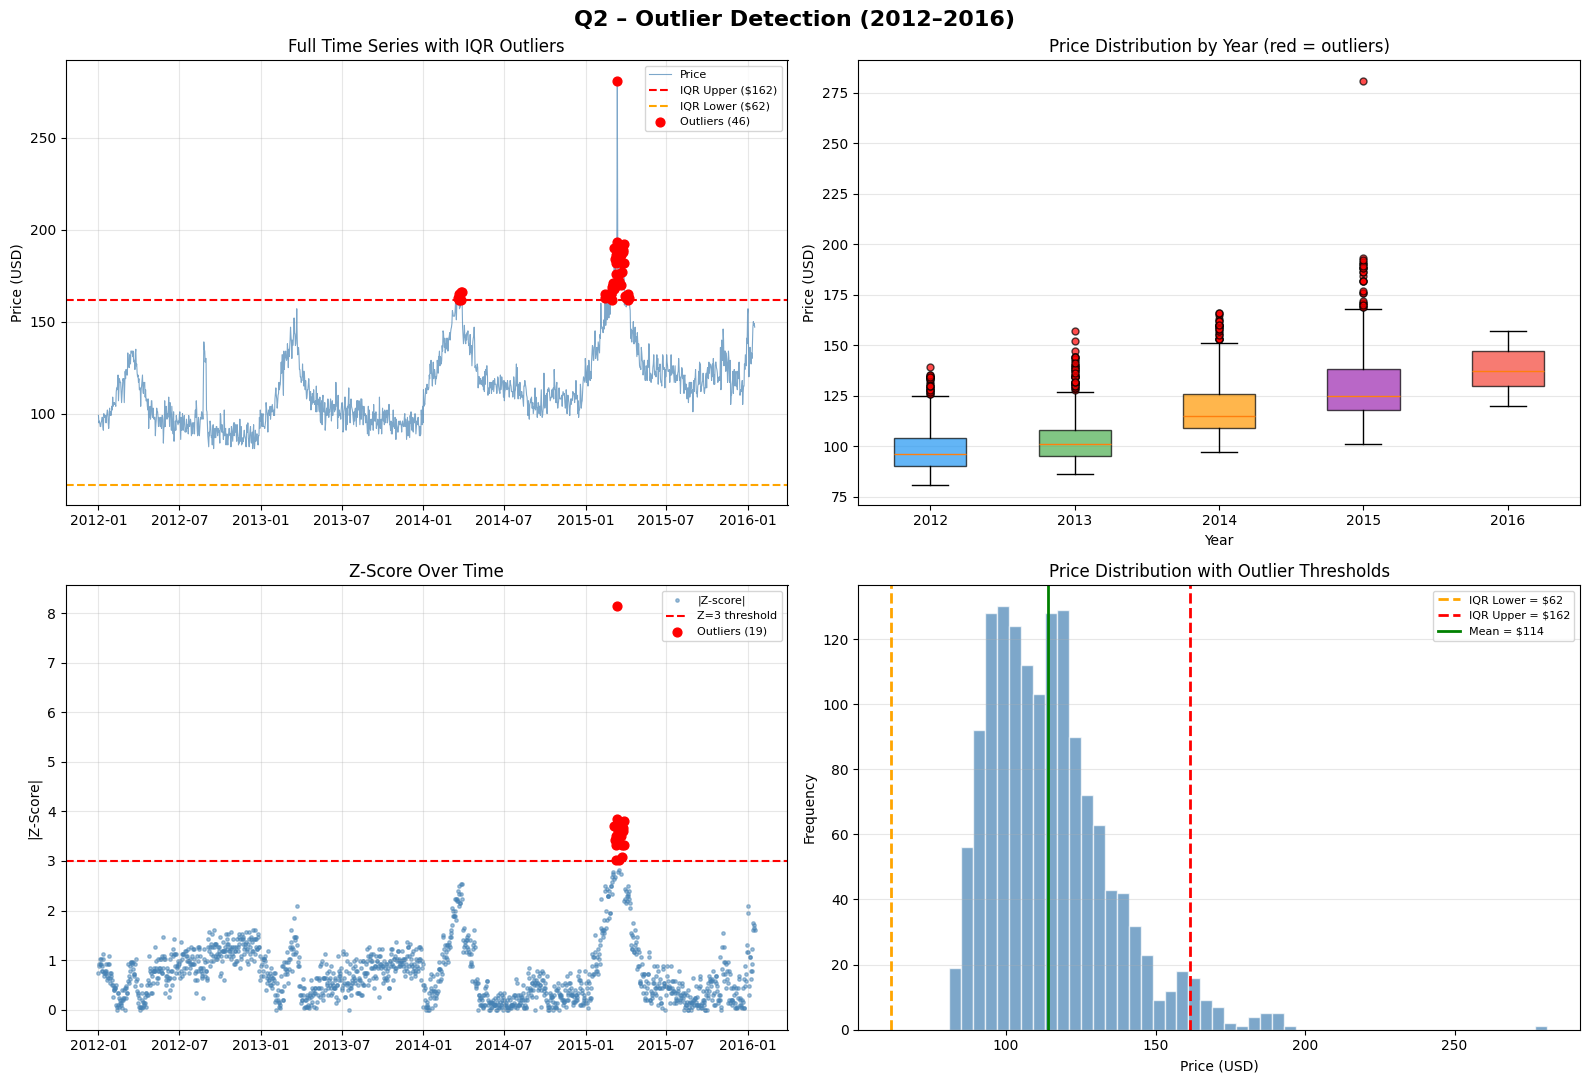


FINDINGS – Q2:
- IQR method found 46 outliers (above $161.5); Z-score found 19 extreme ones.
- All 46 outliers are HIGH-price anomalies — no unusually cheap days detected.
- Outliers span: 2014 Mar; 2015 Feb; 2015 Mar; 2015 Apr.
- Biggest spike: $281 on 2015-03-13 — March 2015 was entirely
  anomalous (avg $181 vs normal ~$140).
  Likely a major local event (conference/festival) driving the demand surge.



In [27]:
# ─────────────────────────────────────────────────────────────────
# Q2: Outlier Detection – Visual + Programmatic
#
# Two methods:
#   - IQR: flags prices outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR]
#          more sensitive, catches moderate anomalies
#   - Z-score: flags |z| > 3, catches only extreme deviations
# ─────────────────────────────────────────────────────────────────

# --- Programmatic Detection ---
Q1, Q3 = df["Price"].quantile(0.25), df["Price"].quantile(0.75)
IQR = Q3 - Q1
iqr_low, iqr_high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
iqr_outliers = df[(df["Price"] < iqr_low) | (df["Price"] > iqr_high)]

z = np.abs(stats.zscore(df["Price"]))
z_outliers = df[z > 3]

print(f"IQR bounds: [${iqr_low:.1f}, ${iqr_high:.1f}]")
print(f"IQR outliers: {len(iqr_outliers)} | Z-score outliers: {len(z_outliers)}")
print(f"\nTop 10 outlier dates:")
print(iqr_outliers.sort_values('Price', ascending=False)[['Date','Price']].head(10).to_string(index=False))

# --- Visual Detection ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Q2 – Outlier Detection (2012–2016)", fontsize=16, fontweight="bold")

ax = axes[0,0]
ax.plot(df["Date"], df["Price"], color="steelblue", linewidth=0.8, alpha=0.7, label="Price")
ax.axhline(iqr_high, color="red", linestyle="--", linewidth=1.5, label=f"IQR Upper (${iqr_high:.0f})")
ax.axhline(iqr_low, color="orange", linestyle="--", linewidth=1.5, label=f"IQR Lower (${iqr_low:.0f})")
ax.scatter(iqr_outliers["Date"], iqr_outliers["Price"], color="red", s=40, zorder=5, label=f"Outliers ({len(iqr_outliers)})")
ax.set(title="Full Time Series with IQR Outliers", ylabel="Price (USD)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0,1]
bp = ax.boxplot([df[df["Year"]==yr]["Price"].values for yr in years],
                patch_artist=True, tick_labels=[str(y) for y in years],
                flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.7))
for patch, yr in zip(bp["boxes"], years):
    patch.set_facecolor(colors_year[yr]); patch.set_alpha(0.7)
ax.set(title="Price Distribution by Year (red = outliers)", xlabel="Year", ylabel="Price (USD)")
ax.grid(alpha=0.3, axis="y")

ax = axes[1,0]
ax.scatter(df["Date"], z, s=6, alpha=0.5, color="steelblue", label="|Z-score|")
ax.axhline(3, color="red", linestyle="--", linewidth=1.5, label="Z=3 threshold")
ax.scatter(df["Date"][z>3], z[z>3], color="red", s=40, zorder=5, label=f"Outliers ({(z>3).sum()})")
ax.set(title="Z-Score Over Time", ylabel="|Z-Score|")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,1]
ax.hist(df["Price"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(iqr_low, color="orange", linestyle="--", linewidth=2, label=f"IQR Lower = ${iqr_low:.0f}")
ax.axvline(iqr_high, color="red", linestyle="--", linewidth=2, label=f"IQR Upper = ${iqr_high:.0f}")
ax.axvline(df["Price"].mean(), color="green", linestyle="-", linewidth=2, label=f"Mean = ${df['Price'].mean():.0f}")
ax.set(title="Price Distribution with Outlier Thresholds", xlabel="Price (USD)", ylabel="Frequency")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

top_outlier       = iqr_outliers.sort_values("Price", ascending=False).iloc[0]
top_outlier_date  = top_outlier["Date"].date()
top_outlier_price = top_outlier["Price"]
low_outliers      = len(iqr_outliers[iqr_outliers["Price"] < iqr_low])
normal_mar_avg    = df[(df["Month"]==3) & (df["Year"]!=2015)]["Price"].mean()

# Build span string: which year+months had outliers
span = iqr_outliers[["Year","Month"]].drop_duplicates().sort_values(["Year","Month"])
span_str = "; ".join([f"{yr} {month_names[m-1]}" for yr, m in zip(span["Year"], span["Month"])])

print(f"""
FINDINGS – Q2:
- IQR method found {len(iqr_outliers)} outliers (above ${iqr_high:.1f}); Z-score found {len(z_outliers)} extreme ones.
- All {len(iqr_outliers)} outliers are HIGH-price anomalies — no unusually cheap days detected.
- Outliers span: {span_str}.
- Biggest spike: ${top_outlier_price} on {top_outlier_date} — March 2015 was entirely
  anomalous (avg ${df[(df['Month']==3)&(df['Year']==2015)]['Price'].mean():.0f} vs normal ~${normal_mar_avg:.0f}).
  Likely a major local event (conference/festival) driving the demand surge.
""")

Historical Feb means: {2012: 111.4, 2013: 119.6, 2014: 134.7, 2015: 153.7}
Trend: +$14.2/year → Projected Feb 2022 mean: $250.5

Daily February 2022 Forecast:
      Date  Forecasted_Price ($)
2022-02-01                 227.7
2022-02-02                 235.9
2022-02-03                 232.0
2022-02-04                 244.6
2022-02-05                 237.3
2022-02-06                 236.4
2022-02-07                 233.0
2022-02-08                 237.8
2022-02-09                 235.9
2022-02-10                 242.6
2022-02-11                 244.6
2022-02-12                 246.5
2022-02-13                 255.2
2022-02-14                 266.7
2022-02-15                 254.2
2022-02-16                 255.2
2022-02-17                 265.8
2022-02-18                 261.4
2022-02-19                 255.2
2022-02-20                 253.7
2022-02-21                 261.9
2022-02-22                 252.3
2022-02-23                 259.0
2022-02-24                 261.0
2022-02-25      

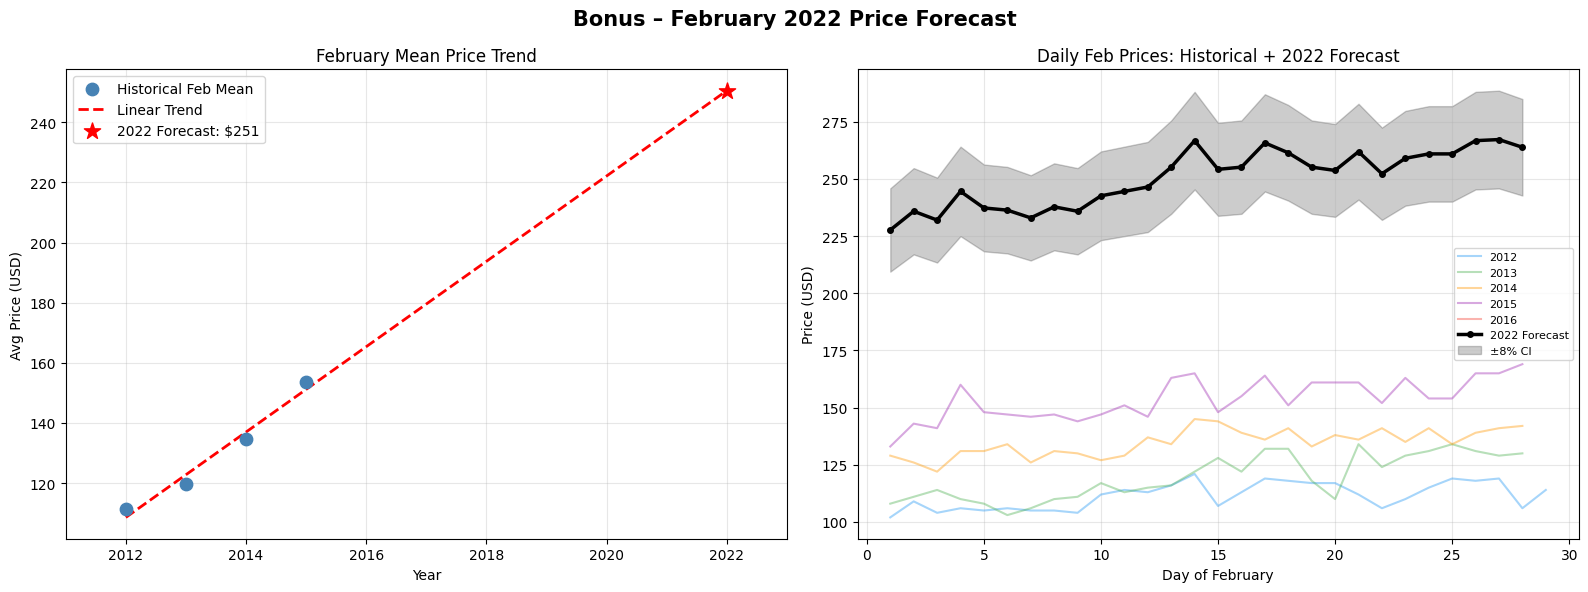


FINDINGS – Bonus:
- Feb prices grew +$14.2/year (2012: $111 → 2015: $154).
- Projected Feb 2022 mean: ~$251 (extrapolated 6 years beyond last data point).
- Highest forecast day: Feb 27 at ~$267.
- Valentine's Day (Feb 14) forecast: ~$267 — a notable mid-month peak.
- Method: historical day-of-year seasonal baseline scaled to linear trend projection.
- Caveat: 6-year extrapolation carries high uncertainty — post-COVID
  demand shifts (not in 2012–2016 data) could significantly affect actual prices.



In [25]:
# ─────────────────────────────────────────────────────────────────
# BONUS: Forecast Daily Hotel Prices for February 2022
#
# Approach: Seasonal Pattern × Linear Trend Projection
#   1. Compute historical avg price per day-of-year (seasonal baseline)
#   2. Fit linear regression to Feb means across 2012–2015
#   3. Project trend to 2022 → expected Feb mean
#   4. Scale daily seasonal pattern to match projected mean
#
# This preserves within-month daily variation while accounting for year-over-year price growth (~$14/year).
# ─────────────────────────────────────────────────────────────────

feb_by_year    = df[df["Month"]==2].groupby("Year")["Price"].mean()
feb_slope, feb_intercept = np.polyfit(feb_by_year.index, feb_by_year.values, 1)
feb_2022_mean  = feb_slope * 2022 + feb_intercept

seasonal       = df.groupby("DayOfYear")["Price"].mean()
feb_2022_dates = pd.date_range("2022-02-01", "2022-02-28")
feb_seasonal   = seasonal[feb_2022_dates.dayofyear]
feb_forecast   = feb_seasonal * (feb_2022_mean / feb_seasonal.mean())

print(f"Historical Feb means: { {yr: round(val,1) for yr, val in feb_by_year.items()} }")
print(f"Trend: +${feb_slope:.1f}/year → Projected Feb 2022 mean: ${feb_2022_mean:.1f}")
print(f"\nDaily February 2022 Forecast:")
print(pd.DataFrame({"Date": feb_2022_dates, "Forecasted_Price ($)": feb_forecast.values.round(1)}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bonus – February 2022 Price Forecast", fontsize=15, fontweight="bold")

ax = axes[0]
ax.scatter(feb_by_year.index, feb_by_year.values, s=80, color="steelblue", zorder=5, label="Historical Feb Mean")
x = np.array([2012, 2016, 2022])
ax.plot(x, feb_slope*x + feb_intercept, "r--", linewidth=2, label="Linear Trend")
ax.scatter([2022], [feb_2022_mean], s=150, color="red", marker="*", zorder=6, label=f"2022 Forecast: ${feb_2022_mean:.0f}")
ax.set(title="February Mean Price Trend", xlabel="Year", ylabel="Avg Price (USD)", xlim=(2011,2023))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for yr in years:
    sub = df[(df["Year"]==yr) & (df["Month"]==2)]
    ax.plot(range(1,len(sub)+1), sub["Price"].values, color=colors_year[yr], alpha=0.4, linewidth=1.5, label=str(yr))
ax.plot(range(1,29), feb_forecast.values, color="black", linewidth=2.5, marker="o", markersize=4, label="2022 Forecast")
ax.fill_between(range(1,29), feb_forecast.values*0.92, feb_forecast.values*1.08, alpha=0.2, color="black", label="±8% CI")
ax.set(title="Daily Feb Prices: Historical + 2022 Forecast", xlabel="Day of February", ylabel="Price (USD)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_day_idx   = feb_forecast.values.argmax()
peak_day_date  = feb_2022_dates[peak_day_idx].strftime("%b %d")
peak_day_price = feb_forecast.values.max()
feb14_price    = feb_forecast.values[13]   # Feb 14 is index 13
feb_first      = feb_by_year.iloc[0]
feb_last       = feb_by_year.iloc[-1]
gap_years      = 2022 - df["Date"].max().year

print(f"""
FINDINGS – Bonus:
- Feb prices grew +${feb_slope:.1f}/year (2012: ${feb_first:.0f} → {feb_by_year.index[-1]}: ${feb_last:.0f}).
- Projected Feb 2022 mean: ~${feb_2022_mean:.0f} (extrapolated {gap_years} years beyond last data point).
- Highest forecast day: {peak_day_date} at ~${peak_day_price:.0f}.
- Valentine's Day (Feb 14) forecast: ~${feb14_price:.0f} — a notable mid-month peak.
- Method: historical day-of-year seasonal baseline scaled to linear trend projection.
- Caveat: {gap_years}-year extrapolation carries high uncertainty — post-COVID
  demand shifts (not in {years[0]}–{years[-1]} data) could significantly affect actual prices.
""")

In [26]:
# ─────────────────────────────────────────────────────────────────
# EXPORT – Save all charts as PNG and download
# ─────────────────────────────────────────────────────────────────

# --- Save Q1 Chart ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q1 – Year-over-Year Repeating Patterns (2012–2016)", fontsize=16, fontweight="bold")
ax = axes[0,0]
for yr in years:
    sub = df[df["Year"] == yr]
    ax.plot(sub["DayOfYear"], sub["Price"], color=colors_year[yr], alpha=0.85, linewidth=1.5, label=str(yr))
ax.set(title="Daily Price Overlay by Day-of-Year", xlabel="Day of Year", ylabel="Price (USD)", xlim=(1,366))
ax.legend(title="Year"); ax.grid(alpha=0.3)
ax = axes[0,1]
bp = ax.boxplot([df[df["Month"]==m]["Price"].values for m in range(1,13)], patch_artist=True, tick_labels=month_names)
for i, patch in enumerate(bp["boxes"]): patch.set_facecolor(plt.cm.RdYlGn(i/12))
ax.set(title="Monthly Price Distribution (All Years)", xlabel="Month", ylabel="Price (USD)"); ax.grid(alpha=0.3, axis="y")
ax = axes[1,0]
for yr in years:
    sub = df[df["Year"]==yr].groupby("Month")["Price"].mean()
    ax.plot(sub.index, sub.values, color=colors_year[yr], marker="o", linewidth=2, markersize=5, label=str(yr))
ax.set(title="Monthly Average Price by Year", xlabel="Month", ylabel="Avg Price (USD)")
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8); ax.legend(title="Year"); ax.grid(alpha=0.3)
ax = axes[1,1]
df_s = df.sort_values("Date").copy()
df_s["Rolling7"] = df_s["Price"].rolling(7, center=True).mean()
for yr in years:
    sub = df_s[df_s["Year"]==yr]
    ax.plot(sub["DayOfYear"], sub["Rolling7"], color=colors_year[yr], linewidth=2, label=str(yr))
ax.set(title="7-Day Rolling Average by Day-of-Year", xlabel="Day of Year", ylabel="Smoothed Price (USD)", xlim=(1,366))
ax.legend(title="Year"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/fig1_yoy_patterns.png", dpi=150, bbox_inches="tight")
plt.close()
print("✓ fig1_yoy_patterns.png saved")

# --- Save Q2 Chart ---
Q1_val, Q3_val = df["Price"].quantile(0.25), df["Price"].quantile(0.75)
IQR_val = Q3_val - Q1_val
iqr_low_s, iqr_high_s = Q1_val - 1.5*IQR_val, Q3_val + 1.5*IQR_val
iqr_out_s = df[(df["Price"] < iqr_low_s) | (df["Price"] > iqr_high_s)]
z_s = np.abs(stats.zscore(df["Price"]))
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Q2 – Outlier Detection (2012–2016)", fontsize=16, fontweight="bold")
ax = axes[0,0]
ax.plot(df["Date"], df["Price"], color="steelblue", linewidth=0.8, alpha=0.7, label="Price")
ax.axhline(iqr_high_s, color="red", linestyle="--", linewidth=1.5, label=f"IQR Upper (${iqr_high_s:.0f})")
ax.axhline(iqr_low_s, color="orange", linestyle="--", linewidth=1.5, label=f"IQR Lower (${iqr_low_s:.0f})")
ax.scatter(iqr_out_s["Date"], iqr_out_s["Price"], color="red", s=40, zorder=5, label=f"Outliers ({len(iqr_out_s)})")
ax.set(title="Full Time Series with IQR Outliers", ylabel="Price (USD)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[0,1]
bp = ax.boxplot([df[df["Year"]==yr]["Price"].values for yr in years], patch_artist=True,
                tick_labels=[str(y) for y in years],
                flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.7))
for patch, yr in zip(bp["boxes"], years): patch.set_facecolor(colors_year[yr]); patch.set_alpha(0.7)
ax.set(title="Price Distribution by Year (red = outliers)", xlabel="Year", ylabel="Price (USD)"); ax.grid(alpha=0.3, axis="y")
ax = axes[1,0]
ax.scatter(df["Date"], z_s, s=6, alpha=0.5, color="steelblue", label="|Z-score|")
ax.axhline(3, color="red", linestyle="--", linewidth=1.5, label="Z=3 threshold")
ax.scatter(df["Date"][z_s>3], z_s[z_s>3], color="red", s=40, zorder=5, label=f"Outliers ({(z_s>3).sum()})")
ax.set(title="Z-Score Over Time", ylabel="|Z-Score|"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1,1]
ax.hist(df["Price"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(iqr_low_s, color="orange", linestyle="--", linewidth=2, label=f"IQR Lower = ${iqr_low_s:.0f}")
ax.axvline(iqr_high_s, color="red", linestyle="--", linewidth=2, label=f"IQR Upper = ${iqr_high_s:.0f}")
ax.axvline(df["Price"].mean(), color="green", linestyle="-", linewidth=2, label=f"Mean = ${df['Price'].mean():.0f}")
ax.set(title="Price Distribution with Thresholds", xlabel="Price (USD)", ylabel="Frequency")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("/content/fig2_outliers.png", dpi=150, bbox_inches="tight")
plt.close()
print("✓ fig2_outliers.png saved")

# --- Save Bonus Chart ---
feb_by_year_s  = df[df["Month"]==2].groupby("Year")["Price"].mean()
feb_slope_s, feb_intercept_s = np.polyfit(feb_by_year_s.index, feb_by_year_s.values, 1)
feb_2022_mean_s = feb_slope_s * 2022 + feb_intercept_s
seasonal_s      = df.groupby("DayOfYear")["Price"].mean()
feb_2022_dates_s = pd.date_range("2022-02-01", "2022-02-28")
feb_seasonal_s  = seasonal_s[feb_2022_dates_s.dayofyear]
feb_forecast_s  = feb_seasonal_s * (feb_2022_mean_s / feb_seasonal_s.mean())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bonus – February 2022 Price Forecast", fontsize=15, fontweight="bold")
ax = axes[0]
ax.scatter(feb_by_year_s.index, feb_by_year_s.values, s=80, color="steelblue", zorder=5, label="Historical Feb Mean")
x = np.array([2012, 2016, 2022])
ax.plot(x, feb_slope_s*x + feb_intercept_s, "r--", linewidth=2, label="Linear Trend")
ax.scatter([2022], [feb_2022_mean_s], s=150, color="red", marker="*", zorder=6, label=f"2022 Forecast: ${feb_2022_mean_s:.0f}")
ax.set(title="February Mean Price Trend", xlabel="Year", ylabel="Avg Price (USD)", xlim=(2011,2023))
ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
for yr in years:
    sub = df[(df["Year"]==yr) & (df["Month"]==2)]
    ax.plot(range(1,len(sub)+1), sub["Price"].values, color=colors_year[yr], alpha=0.4, linewidth=1.5, label=str(yr))
ax.plot(range(1,29), feb_forecast_s.values, color="black", linewidth=2.5, marker="o", markersize=4, label="2022 Forecast")
ax.fill_between(range(1,29), feb_forecast_s.values*0.92, feb_forecast_s.values*1.08, alpha=0.2, color="black", label="±8% CI")
ax.set(title="Daily Feb Prices: Historical + 2022 Forecast", xlabel="Day of February", ylabel="Price (USD)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/fig3_forecast.png", dpi=150, bbox_inches="tight")
plt.close()
print("✓ fig3_forecast.png saved")

# --- Download all 3 ---
from google.colab import files
files.download("/content/fig1_yoy_patterns.png")
files.download("/content/fig2_outliers.png")
files.download("/content/fig3_forecast.png")
print("\n✓ All 3 charts downloaded to your computer!")

✓ fig1_yoy_patterns.png saved
✓ fig2_outliers.png saved
✓ fig3_forecast.png saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ All 3 charts downloaded to your computer!
